<a href="https://colab.research.google.com/github/mahammadaftab/Machine-Learning-Lab/blob/main/Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
data=np.random.rand(100)
labels=["Class1" if x<=0.5 else"Class2" for x in data[:50]]

In [3]:
def knn_classifier(train_data,train_labels,test_point,k):
  distances=sorted([(abs(test_point - train_data[i]),train_labels[i]) for i in range(len(train_data))],key=lambda x:x[0])
  k_nearest_labels=[label for _,label in distances[:k]]
  return Counter(k_nearest_labels).most_common(1)[0][0]

In [4]:
train_data,train_labels=data[:50],labels
test_data=data[50:]
k_values=[1,2,3,4,5,20,30]
print("--K-Nearest Neighbors Classifier--")
print("Training dataset:First 50 points labeled based on (x<=0.5-> Class1, x>0.5-> Class2)")
print("Testing dataset: Remaining 50 points to be classified\n")
result={k:[knn_classifier(train_data,train_labels,test_point,k)for test_point in test_data]for k in k_values}

--K-Nearest Neighbors Classifier--
Training dataset:First 50 points labeled based on (x<=0.5-> Class1, x>0.5-> Class2)
Testing dataset: Remaining 50 points to be classified



In [18]:
for k, classified_labels in result.items():
  print(f"Result for k={k}:")
  for i,label in enumerate(classified_labels,start=51):
    print(f"point x{i}(value:{test_data[i-51]:.4f})is classified as {label}")
  print()
print("classification complete.\n")

Result for k=1:
point x51(value:0.0767)is classified as Class1
point x52(value:0.2133)is classified as Class1
point x53(value:0.3442)is classified as Class1
point x54(value:0.8901)is classified as Class2
point x55(value:0.4705)is classified as Class1
point x56(value:0.2545)is classified as Class1
point x57(value:0.5782)is classified as Class2
point x58(value:0.5120)is classified as Class2
point x59(value:0.3957)is classified as Class1
point x60(value:0.5707)is classified as Class2
point x61(value:0.7471)is classified as Class2
point x62(value:0.5020)is classified as Class2
point x63(value:0.2691)is classified as Class1
point x64(value:0.8775)is classified as Class2
point x65(value:0.8832)is classified as Class2
point x66(value:0.0197)is classified as Class1
point x67(value:0.9709)is classified as Class2
point x68(value:0.4568)is classified as Class1
point x69(value:0.0175)is classified as Class1
point x70(value:0.2093)is classified as Class1
point x71(value:0.7490)is classified as Clas

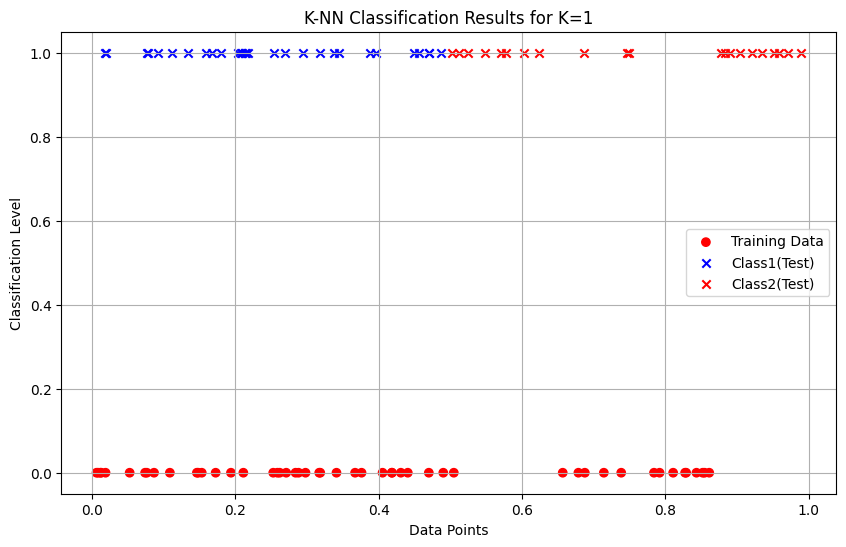

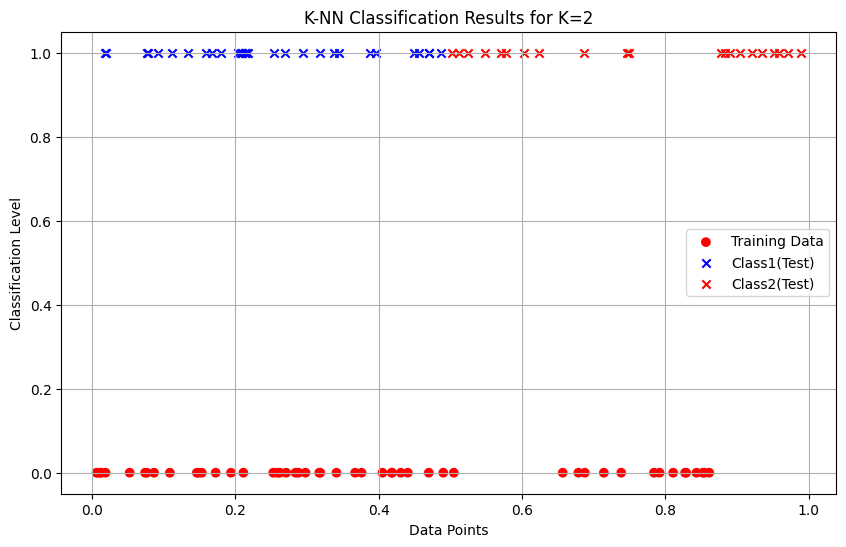

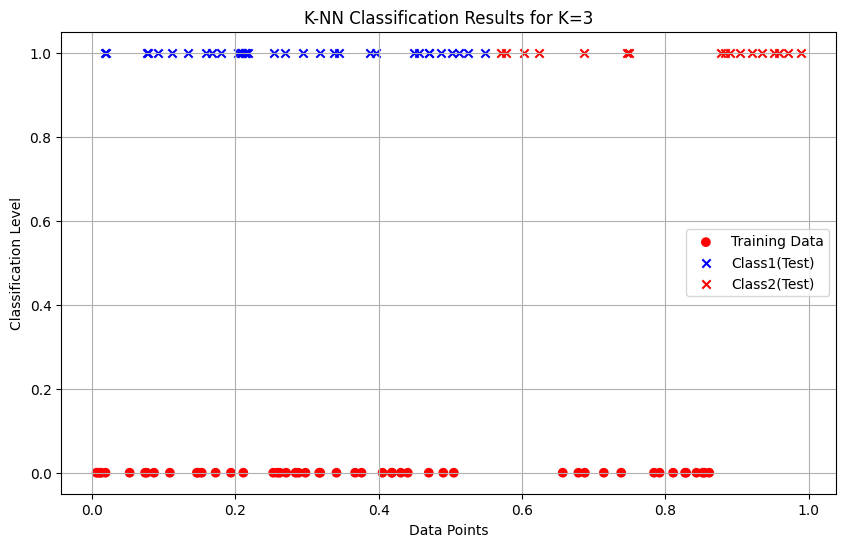

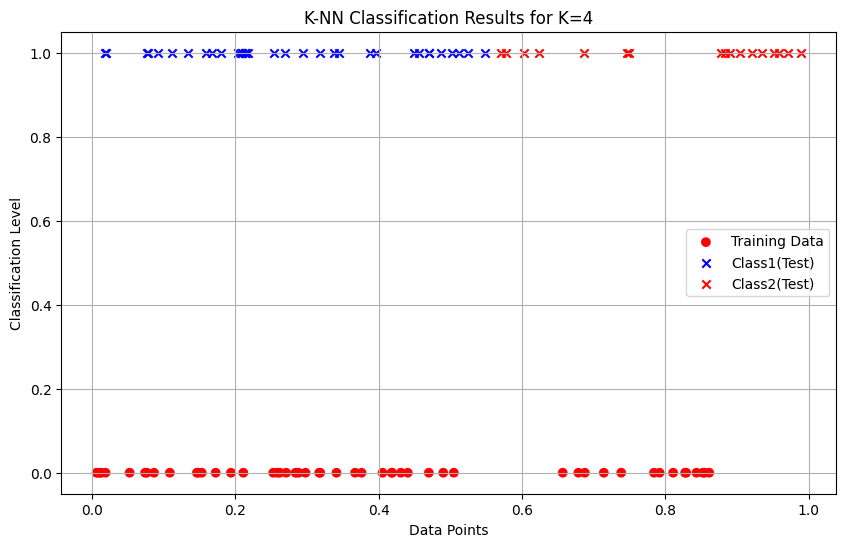

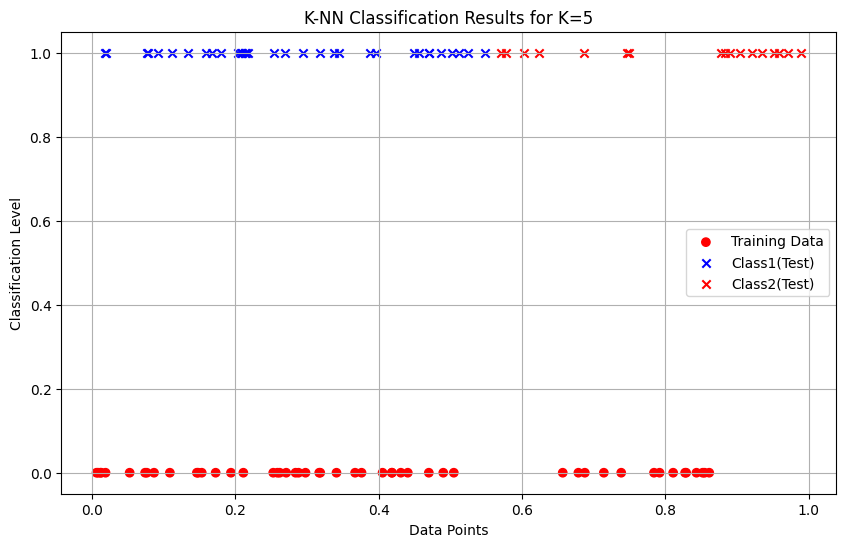

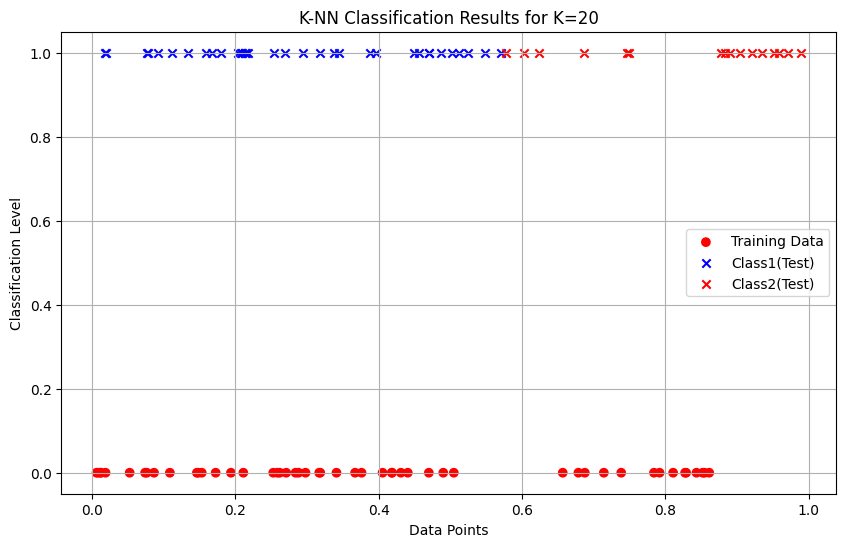

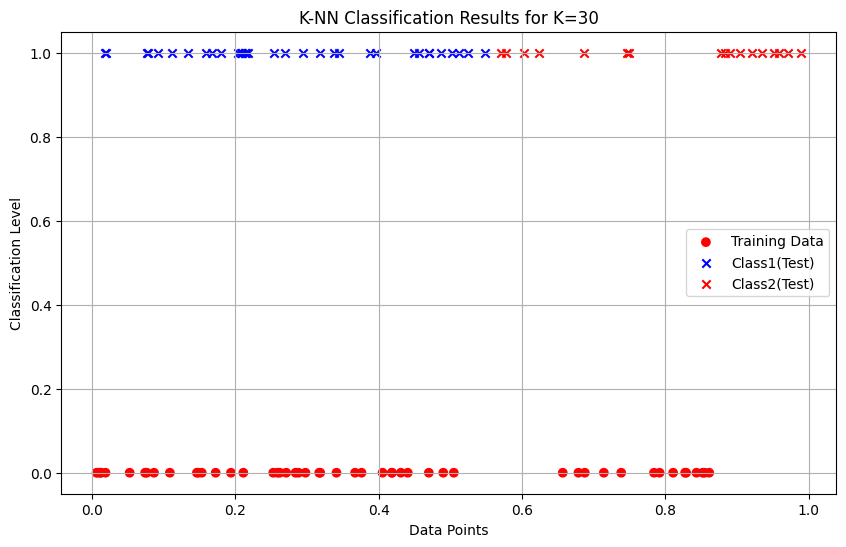

In [24]:
for k, classified_labels in result.items():
  class1_points=[test_data[i] for i in range(len(test_data)) if classified_labels[i]=="Class1"]
  class2_points=[test_data[i] for i in range(len(test_data)) if classified_labels[i]=="Class2"]
  plt.figure(figsize=(10,6))
  plt.scatter(train_data,[0]*len(train_data),c=["blue" if label=="class1" else "red" for label in train_labels],label="Training Data",marker="o")
  plt.scatter(class1_points,[1]*len(class1_points),c="blue",label="Class1(Test)",marker="x")
  plt.scatter(class2_points,[1]*len(class2_points),c="red",label="Class2(Test)",marker="x")
  plt.title(f"K-NN Classification Results for K={k}")
  plt.xlabel("Data Points")
  plt.ylabel("Classification Level")
  plt.legend()
  plt.grid(True)
  plt.show()